# Libraries

In [87]:
import os
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from datetime import datetime
from scipy.interpolate import griddata #Contour plots
from matplotlib import rcParams

# Set global font to Times New Roman
rcParams['font.family'] = 'serif'
rcParams['font.serif'] = ['Times New Roman']

In [88]:
ls

 Volume in drive C is Windows
 Volume Serial Number is F86E-9ECB

 Directory of C:\Users\GOVEAALP\OneDrive - VITO\Documents\Experiments\2024\K2SO4\20240531 - Ag60 GDE_0.6 M K2SO4_pH1

11-Aug-26  08:48 AM    <DIR>          .
07-Jun-26  07:23 PM    <DIR>          ..
07-Jun-26  08:16 PM    <DIR>          .ipynb_checkpoints
14-Jun-24  12:01 PM           637,811 0.6M Cs2SO4_pH1.xlsx
01-Jun-24  04:50 PM            42,901 0p6M_pH1 K2SO4_20240601_1450_1min - Copy.xlsx
29-Jul-26  05:31 PM            57,059 0p6M_pH1 K2SO4_20240601_1450_1min.xlsx
01-Jun-24  04:50 PM            12,943 0p6M_pH1 K2SO4_20240601_1450_5min.xlsx
01-Jun-24  04:50 PM           348,181 0p6M_pH1 K2SO4_20240601_1450_Line_1.csv
12-May-25  01:59 PM           886,511 20240531 - Ag60 GDE_0.6 M K2SO4_pH1.ipynb
07-Jun-26  08:28 PM           600,979 20240531 - Ag60 GDE_0.6 M K2SO4_pH1-CORRECTED - Copy.ipynb
11-Aug-26  08:48 AM           529,763 20240531 - Ag60 GDE_0.6 M K2SO4_pH1-CORRECTED.ipynb
11-Aug-26  08:45 AM               54

# Load Data

In [89]:
Book = "Book_20240531 - Ag60 GDE_0.6 M K2SO4_pH1.xlsx"
Book = pd.read_excel(Book)
Book

,Electrode,Inlet flow rate,Flow rate (ml min-1),Catholyte,Anolyte,Membrane,Applied current / A,Time,Duration / h,area(H2),...,c(H2),c(CO),c(CO2),c(O2),FE(H2),FE(CO),FE(CH4),Total FE,Carbon efficiency,Unnamed: 24
0,Ag60 GDE in PTFE holder,60,58.815907,0.3 M K2SO4,0.05 M H2SO4,CCM-CEM,0.000,2024-05-31 18:56:33.853,0.000000,0.000000,...,0.000000,0.0,0.000000,0.000000,0.000000,0.0,NaN,0.000000,0.0,0.0000
1,Ag60 GDE in PTFE holder,60,60.413028,0.3 M K2SO4,0.05 M H2SO4,CCM-CEM,-0.125,2024-05-31 19:01:41.000,0.085319,0.383402,...,0.003572,0.0,0.995680,0.000211,0.228503,0.0,NaN,0.228503,0.0,NaN
2,Ag60 GDE in PTFE holder,60,61.367047,0.3 M K2SO4,0.05 M H2SO4,CCM-CEM,-0.125,2024-05-31 19:24:12.000,0.460596,1.572683,...,0.014707,0.0,0.984731,0.000136,0.955593,0.0,NaN,0.955593,0.0,105.3037
3,Ag60 GDE in PTFE holder,60,61.254046,0.3 M K2SO4,0.05 M H2SO4,CCM-CEM,-0.125,2024-05-31 19:46:42.000,0.835596,1.584256,...,0.014787,0.0,0.984772,0.000100,0.959019,0.0,NaN,0.959019,0.0,NaN
4,Ag60 GDE in PTFE holder,60,61.057261,0.3 M K2SO4,0.05 M H2SO4,CCM-CEM,-0.125,2024-05-31 20:09:15.000,1.211430,1.576996,...,0.014738,0.0,0.985001,0.000049,0.952809,0.0,NaN,0.952809,0.0,105.3953
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
57,Ag60 GDE in PTFE holder,60,72.762541,0.3 M K2SO4,0.05 M H2SO4,CCM-CEM,-0.500,2024-06-01 13:15:59.000,18.323652,15.997969,...,0.153794,0.0,0.845942,0.000234,2.962169,0.0,NaN,2.962169,0.0,NaN
58,Ag60 GDE in PTFE holder,60,72.620088,0.3 M K2SO4,0.05 M H2SO4,CCM-CEM,-0.500,2024-06-01 13:30:59.000,18.573652,15.991267,...,0.154028,0.0,0.845779,0.000193,2.960858,0.0,NaN,2.960858,0.0,87.8094
59,Ag60 GDE in PTFE holder,60,72.654905,0.3 M K2SO4,0.05 M H2SO4,CCM-CEM,-0.500,2024-06-01 13:45:59.000,18.823652,15.970483,...,0.153890,0.0,0.845923,0.000187,2.959622,0.0,NaN,2.959622,0.0,NaN
60,Ag60 GDE in PTFE holder,60,72.581455,0.3 M K2SO4,0.05 M H2SO4,CCM-CEM,-0.500,2024-06-01 14:01:01.000,19.074207,15.955338,...,0.153654,0.0,0.846157,0.000189,2.952098,0.0,NaN,2.952098,0.0,87.8647


In [90]:
Book["Duration / h"] = round(Book["Duration / h"],2)
Book["Flow rate (ml min-1)"] = round(Book["Flow rate (ml min-1)"],2)
# Flow_df = Book[["Time", "Duration / h", "Flow rate (ml min-1)"]].copy()
Book["GC_flow_rate_ml_min"] = Book["Flow rate (ml min-1)"]
Book.tail(3)

,Electrode,Inlet flow rate,Flow rate (ml min-1),Catholyte,Anolyte,Membrane,Applied current / A,Time,Duration / h,area(H2),...,c(CO),c(CO2),c(O2),FE(H2),FE(CO),FE(CH4),Total FE,Carbon efficiency,Unnamed: 24,GC_flow_rate_ml_min
59,Ag60 GDE in PTFE holder,60,72.65,0.3 M K2SO4,0.05 M H2SO4,CCM-CEM,-0.5,2024-06-01 13:45:59,18.82,15.970483,...,0.0,0.845923,0.000187,2.959622,0.0,NaN,2.959622,0.0,NaN,72.65
60,Ag60 GDE in PTFE holder,60,72.58,0.3 M K2SO4,0.05 M H2SO4,CCM-CEM,-0.5,2024-06-01 14:01:01,19.07,15.955338,...,0.0,0.846157,0.000189,2.952098,0.0,NaN,2.952098,0.0,87.8647,72.58
61,Ag60 GDE in PTFE holder,60,55.96,0.3 M K2SO4,0.05 M H2SO4,CCM-CEM,-0.5,2024-06-01 14:16:01,19.32,11.577883,...,0.0,0.889082,0.000188,1.639605,0.0,NaN,1.639605,0.0,NaN,55.96


### Temp from pH meter

In [91]:
Temp = "2024-06-01_140946.csv"
Temp = pd.read_csv(Temp)
Temp[["Supp Reading 1", "Supp Units 1"]]
Temp_C_mean = Temp["Supp Reading 1"].mean()
Temp_C_median = Temp["Supp Reading 1"].median()

print("Temp C mean:", Temp_C_mean)
print("Temp C median:", Temp_C_median)

Temp C mean: 24.58597422289613
Temp C median: 24.0


### Power Supply

In [92]:
power_sup = "Power supply_1.csv"
power_sup = pd.read_csv(power_sup, sep=";")
power_sup.head(2)

,U set,U actual,I set,I actual,P set,P actual,R set,R actual,R mode,Output/Input,Device mode,Error,Time
0,0.00V,0.17V,0.000A,0.000A,320.00W,0.00W,NaN,NaN,NaN,On,CV,NaN,31.05.2024 18:56:33.853
1,40.00V,2.09V,0.100A,0.112A,320.00W,0.00W,NaN,NaN,NaN,On,CC,NaN,31.05.2024 18:56:38.852


In [93]:
power_sup.groupby("I set", group_keys=True)[['U actual']].apply(lambda x: x).head(3)

U actual
I set                
0.000A 0        0.17V
       13845    1.68V
       13846    1.66V

In [94]:
power_sup["Time"] = pd.to_datetime(
    power_sup["Time"],
    format="%d.%m.%Y %H:%M:%S.%f"
)

power_sup["I actual"] = (
    power_sup["I actual"]
    .str.replace("A", "", regex=False)
    .str.strip()
    .astype(float)
)
power_sup["U actual"] = (
    power_sup["U actual"]
    .str.replace("V", "", regex=False)
    .str.strip()
    .astype(float)
)

# Set time as index
power_sup = power_sup.set_index("Time")

# Mean current and voltage every 2 hours
power_summary = (
    power_sup.resample("2h")
    .agg({
        "I actual": "max",
        "U actual": "max"
    })
    .reset_index()
)

# Rename column
# I_mean = I_mean.rename(columns={"I actual": "I actual_mean (A)"})
print(power_summary)

                  Time  I actual  U actual
0  2024-05-31 18:00:00     0.122      2.43
1  2024-05-31 20:00:00     0.271      2.82
2  2024-05-31 22:00:00     0.519      3.40
3  2024-06-01 00:00:00     0.769      3.83
4  2024-06-01 02:00:00     1.022      4.34
5  2024-06-01 04:00:00     1.514      5.22
6  2024-06-01 06:00:00     2.016      6.22
7  2024-06-01 08:00:00     3.013      8.05
8  2024-06-01 10:00:00     3.019      7.93
9  2024-06-01 12:00:00     1.515      5.19
10 2024-06-01 14:00:00     1.513      5.02


In [95]:
# cell_voltage = power_summary.iloc[3:].reset_index(drop=True) #Power supply was recording before the experiment
# power_summary.loc[power_summary.index[0], "I actual"] = 0 #The first row will be taken is 0, not current was input
power_summary = power_summary.iloc[:-3].reset_index(drop=True) #after 16h
print(power_summary)

                 Time  I actual  U actual
0 2024-05-31 18:00:00     0.122      2.43
1 2024-05-31 20:00:00     0.271      2.82
2 2024-05-31 22:00:00     0.519      3.40
3 2024-06-01 00:00:00     0.769      3.83
4 2024-06-01 02:00:00     1.022      4.34
5 2024-06-01 04:00:00     1.514      5.22
6 2024-06-01 06:00:00     2.016      6.22
7 2024-06-01 08:00:00     3.013      8.05


In [96]:
dfcell_voltage = pd.DataFrame(power_summary)
dfcell_voltage = dfcell_voltage.rename(columns={"U actual": "Voltage"})
dfcell_voltage = dfcell_voltage.set_index("I actual")
dfcell_voltage = dfcell_voltage.drop(columns=["Time"])
dfcell_voltage

,Voltage
I actual,
0.122,2.43
0.271,2.82
0.519,3.40
0.769,3.83
1.022,4.34
1.514,5.22
2.016,6.22
3.013,8.05


In [97]:
# power_sup["U actual"] = power_sup["U actual"].str.replace("V", "", regex=False).astype(float)
# power_sup["I set"] = power_sup["I set"].str.replace("A", "", regex=False).astype(float)
# cell_voltage = power_sup.groupby("I set")["U actual"].mean()
# cell_voltage

In [98]:
dfcell_voltage["Current Density [mA cm-2]"] = dfcell_voltage.index*10
dfcell_voltage

,Voltage,Current Density [mA cm-2]
I actual,,
0.122,2.43,1.22
0.271,2.82,2.71
0.519,3.40,5.19
0.769,3.83,7.69
1.022,4.34,10.22
1.514,5.22,15.14
2.016,6.22,20.16
3.013,8.05,30.13


## Flow rate

In [99]:
flow_rate = "0p6M_pH1 K2SO4_20240601_1450_1min.xlsx"
flow_rate = pd.read_excel(flow_rate, sheet_name="Process data")
flow_rate.head(20)

,Unnamed: 0,Unnamed: 1,Unnamed: 2
0,Report generated (UTC),2024-06-01 14:50:00.470000,NaN
1,Software version,Aurora 1.0.6,NaN
2,Instrument name,0p6M_pH1 K2SO4,NaN
3,Instrument model name,BPC Go,NaN
4,Ethernet mac address,f8:dc:7a:6f:0d:ec,NaN
5,Agitation state,Off,NaN
6,Agitation phase,Single,NaN
7,Agitation phase speed (%),30,NaN
8,Gas normalisation,Unnormalised,NaN
9,NaN,NaN,NaN


In [100]:
flow_rate = flow_rate.iloc[18:].reset_index(drop=True)
flow_rate = flow_rate.rename(columns={
    "Unnamed: 0": "Time (UTC)",
    "Unnamed: 1": "Gas flow rate [ml/min]",
    "Unnamed: 2": "Specific gas production [ml/min/l]"
})
flow_rate.head(10)

,Time (UTC),Gas flow rate [ml/min],Specific gas production [ml/min/l]
0,2024-05-31 16:56:00.038000,58.815907,29.407953
1,2024-05-31 16:57:00,60.05001,30.025005
2,2024-05-31 16:57:59.962000,60.726233,30.363116
3,2024-05-31 16:59:00.010000,60.912474,30.456237
4,2024-05-31 16:59:59.971000,60.899605,30.449802
5,2024-05-31 17:01:00.019000,60.413028,30.206514
6,2024-05-31 17:01:59.981000,60.809599,30.4048
7,2024-05-31 17:03:00.029000,60.589848,30.294924
8,2024-05-31 17:03:59.990000,60.824764,30.412382
9,2024-05-31 17:05:00.038000,61.223105,30.611553


In [101]:
flow_rate["Time (UTC)"] = pd.to_datetime(
    flow_rate["Time (UTC)"],
    format="%d.%m.%Y %H:%M:%S.%f"
)

# Set time as index
flow_rate = flow_rate.set_index("Time (UTC)")

# Mean current and voltage every 2 hours
flow_rate = (
    flow_rate.resample("2h")
    .agg(Flow_rate_min=("Gas flow rate [ml/min]", "min"), 
         Flow_rate_max=("Gas flow rate [ml/min]", "max"),
         Flow_rate_mean=("Gas flow rate [ml/min]", "mean"),
         Flow_rate_median=("Gas flow rate [ml/min]", "median"))
    .reset_index()
)

print(flow_rate)

            Time (UTC) Flow_rate_min Flow_rate_max Flow_rate_mean  \
0  2024-05-31 16:00:00     58.815907     62.169426      61.170678   
1  2024-05-31 18:00:00     61.057261     64.118925      62.720059   
2  2024-05-31 20:00:00     62.819915     66.272852      64.633494   
3  2024-05-31 22:00:00     64.909426     68.577046      66.636112   
4  2024-06-01 00:00:00     66.996028     70.183705      68.586339   
5  2024-06-01 02:00:00     68.900073     75.031048      71.877238   
6  2024-06-01 04:00:00      73.06306     79.209369      76.052591   
7  2024-06-01 06:00:00      77.39137     86.876933      82.091481   
8  2024-06-01 08:00:00     69.813847     85.754164      77.630898   
9  2024-06-01 10:00:00     71.429395     73.123017      72.360599   
10 2024-06-01 12:00:00     55.442635     73.081884       59.68163   
11 2024-06-01 14:00:00     52.980944     61.054174      60.057674   

   Flow_rate_median  
0         61.260993  
1         63.126839  
2         65.356896  
3         67.2

In [102]:
# ---- physical constants ---- For FE% later
F   = 96485        # Faraday constant                   [C/mol]
R   = 8.314        # ideal-gas constant                 [J/(mol*K)]
T   = Temp_C_median + 273.15     # gas temperature at the meter       [K]  (~23.3 degC)
P   = 101325       # pressure                           [Pa]
V_m = (R*T/P)*1000 # molar volume of an ideal gas       [L/mol]  -> the "24.3"

# ---- wet-to-dry correction ----
# The flow meter reads the wet gas leaving the cell. Assuming saturation at the
# meter temperature, water occupies x_H2O of the stream; the remaining fraction
# is product + carrier. p_sat from the Buck equation.
T_C   = Temp_C_median
P_SAT = 0.61121*np.exp((18.678 - T_C/234.5)*(T_C/(257.14 + T_C))) * 1000   # Pa
X_H2O = P_SAT / P                  # 0.0282 at 23.3 degC
DRY   = 1 - X_H2O                  # 0.9718

# ---- reaction / cell parameters ----
n_e   = 2          # electrons per molecule:  H2 (2 H+ + 2 e- -> H2)
                   #                          CO (CO2 + 2 H+ + 2 e- -> CO + H2O)
A_cm2 = 10         # geometric electrode area           [cm^2]

print(f"V_m   = {V_m:.3f} L/mol")
print(f"p_sat = {P_SAT/1000:.4f} kPa -> x(H2O) = {X_H2O*100:.2f} % -> dry factor {DRY:.5f}")

V_m   = 24.382 L/mol
p_sat = 2.9845 kPa -> x(H2O) = 2.95 % -> dry factor 0.97055


In [103]:
FLOW_COLS = ["Flow_rate_min", "Flow_rate_max", "Flow_rate_mean", "Flow_rate_median"]
for c in FLOW_COLS:
    flow_rate[c + "_dry"] = flow_rate[c] * DRY

# FLOW_COLS = ["Flow_rate_min", "Flow_rate_max", "Flow_rate_mean", "Flow_rate_median"]

# for c in FLOW_COLS:
#     flow_rate[c + "_corr"] = flow_rate[c] * 0.9723

# flow_rate

In [104]:
print(flow_rate)

            Time (UTC) Flow_rate_min Flow_rate_max Flow_rate_mean  \
0  2024-05-31 16:00:00     58.815907     62.169426      61.170678   
1  2024-05-31 18:00:00     61.057261     64.118925      62.720059   
2  2024-05-31 20:00:00     62.819915     66.272852      64.633494   
3  2024-05-31 22:00:00     64.909426     68.577046      66.636112   
4  2024-06-01 00:00:00     66.996028     70.183705      68.586339   
5  2024-06-01 02:00:00     68.900073     75.031048      71.877238   
6  2024-06-01 04:00:00      73.06306     79.209369      76.052591   
7  2024-06-01 06:00:00      77.39137     86.876933      82.091481   
8  2024-06-01 08:00:00     69.813847     85.754164      77.630898   
9  2024-06-01 10:00:00     71.429395     73.123017      72.360599   
10 2024-06-01 12:00:00     55.442635     73.081884       59.68163   
11 2024-06-01 14:00:00     52.980944     61.054174      60.057674   

   Flow_rate_median Flow_rate_min_dry Flow_rate_max_dry Flow_rate_mean_dry  \
0         61.260993     

In [105]:
dfflow_rate = pd.DataFrame(flow_rate)
dfflow_rate['Current [A]'] = power_summary['I actual']
dfflow_rate['Voltage'] = power_summary['U actual']
dfflow_rate = dfflow_rate.iloc[:-4].reset_index(drop=True)
dfflow_rate

,Time (UTC),Flow_rate_min,Flow_rate_max,Flow_rate_mean,Flow_rate_median,Flow_rate_min_dry,Flow_rate_max_dry,Flow_rate_mean_dry,Flow_rate_median_dry,Current [A],Voltage
0,2024-05-31 16:00:00,58.815907,62.169426,61.170678,61.260993,57.083508,60.33825,59.36892,59.456575,0.122,2.43
1,2024-05-31 18:00:00,61.057261,64.118925,62.720059,63.126839,59.258844,62.230328,60.872665,61.267463,0.271,2.82
2,2024-05-31 20:00:00,62.819915,66.272852,64.633494,65.356896,60.969579,64.320812,62.72974,63.431835,0.519,3.40
3,2024-05-31 22:00:00,64.909426,68.577046,66.636112,67.241855,62.997545,66.557136,64.673372,65.261273,0.769,3.83
4,2024-06-01 00:00:00,66.996028,70.183705,68.586339,69.392505,65.022687,68.116472,66.566156,67.348576,1.022,4.34
5,2024-06-01 02:00:00,68.900073,75.031048,71.877238,73.596573,66.870649,72.821038,69.760122,71.428815,1.514,5.22
6,2024-06-01 04:00:00,73.06306,79.209369,76.052591,77.796327,70.911017,76.876289,73.812492,75.504867,2.016,6.22
7,2024-06-01 06:00:00,77.39137,86.876933,82.091481,85.288779,75.111838,84.318008,79.673509,82.776632,3.013,8.05


In [106]:
# dfflow_rate.to_csv('20240531_0.6M K2SO4_pH1_flow rate.csv')

## Energy consumption

Units: cm2 to m2: 1000cm2 is 1m2.  <br>
mA to A: 1000mA is 1A.  <br>
hrs to sec: 1hr is 3600 <br>
10cm2 = 0.001m2. <br> 2hr = 7200 <br>
1Wh = 3600J

*Energy consumption* = Current density [A cm2]* time [s] * cell voltage [V] * area of the electrode [m2]

In [107]:
electrode_area = 10/10000 #10cm2 to m2
time = 2*3600 #2hrs

dfcell_voltage["Current Density [A m-2]"] = dfcell_voltage["Current Density [mA cm-2]"]*100000/1000
dfcell_voltage.head(3)

,Voltage,Current Density [mA cm-2],Current Density [A m-2]
I actual,,,
0.122,2.43,1.22,122.0
0.271,2.82,2.71,271.0
0.519,3.40,5.19,519.0


In [108]:
dfcell_voltage["Energy Consumption [J]"] = dfcell_voltage.index * time * dfcell_voltage["Voltage"]
dfcell_voltage

,Voltage,Current Density [mA cm-2],Current Density [A m-2],Energy Consumption [J]
I actual,,,,
0.122,2.43,1.22,122.0,2134.512
0.271,2.82,2.71,271.0,5502.384
0.519,3.40,5.19,519.0,12705.120
0.769,3.83,7.69,769.0,21205.944
1.022,4.34,10.22,1022.0,31935.456
1.514,5.22,15.14,1514.0,56902.176
2.016,6.22,20.16,2016.0,90284.544
3.013,8.05,30.13,3013.0,174633.480


In [109]:
dfcell_voltage["Energy Consumption [kWh]"] = dfcell_voltage["Energy Consumption [J]"]/3600000 #1kWh is 3.6xe6 joules
dfcell_voltage

,Voltage,Current Density [mA cm-2],Current Density [A m-2],Energy Consumption [J],Energy Consumption [kWh]
I actual,,,,,
0.122,2.43,1.22,122.0,2134.512,0.000593
0.271,2.82,2.71,271.0,5502.384,0.001528
0.519,3.40,5.19,519.0,12705.120,0.003529
0.769,3.83,7.69,769.0,21205.944,0.005891
1.022,4.34,10.22,1022.0,31935.456,0.008871
1.514,5.22,15.14,1514.0,56902.176,0.015806
2.016,6.22,20.16,2016.0,90284.544,0.025079
3.013,8.05,30.13,3013.0,174633.480,0.048509


In [110]:
# dfcell_voltage.to_csv('20240531_0.6 M K2SO4_pH1_Energy Consumption.csv')

## FE(CO) and FE(H2)

## Integer Duration ("Applied Current /A" - Values optimization)

In [111]:
Book['Integer Duration'] = np.floor(Book['Duration / h'])
Book = Book[Book['Integer Duration'] <= 15].copy() #If 16 takes all the data after the 16h running
Book

,Electrode,Inlet flow rate,Flow rate (ml min-1),Catholyte,Anolyte,Membrane,Applied current / A,Time,Duration / h,area(H2),...,c(CO2),c(O2),FE(H2),FE(CO),FE(CH4),Total FE,Carbon efficiency,Unnamed: 24,GC_flow_rate_ml_min,Integer Duration
0,Ag60 GDE in PTFE holder,60,58.82,0.3 M K2SO4,0.05 M H2SO4,CCM-CEM,0.000,2024-05-31 18:56:33.853,0.00,0.000000,...,0.000000,0.000000,0.000000,0.000000,NaN,0.000000,0.000000,0.0000,58.82,0.0
1,Ag60 GDE in PTFE holder,60,60.41,0.3 M K2SO4,0.05 M H2SO4,CCM-CEM,-0.125,2024-05-31 19:01:41.000,0.09,0.383402,...,0.995680,0.000211,0.228503,0.000000,NaN,0.228503,0.000000,NaN,60.41,0.0
2,Ag60 GDE in PTFE holder,60,61.37,0.3 M K2SO4,0.05 M H2SO4,CCM-CEM,-0.125,2024-05-31 19:24:12.000,0.46,1.572683,...,0.984731,0.000136,0.955593,0.000000,NaN,0.955593,0.000000,105.3037,61.37,0.0
3,Ag60 GDE in PTFE holder,60,61.25,0.3 M K2SO4,0.05 M H2SO4,CCM-CEM,-0.125,2024-05-31 19:46:42.000,0.84,1.584256,...,0.984772,0.000100,0.959019,0.000000,NaN,0.959019,0.000000,NaN,61.25,0.0
4,Ag60 GDE in PTFE holder,60,61.06,0.3 M K2SO4,0.05 M H2SO4,CCM-CEM,-0.125,2024-05-31 20:09:15.000,1.21,1.576996,...,0.985001,0.000049,0.952809,0.000000,NaN,0.952809,0.000000,105.3953,61.06,1.0
5,Ag60 GDE in PTFE holder,60,61.70,0.3 M K2SO4,0.05 M H2SO4,CCM-CEM,-0.125,2024-05-31 20:31:47.000,1.59,1.622391,...,0.984613,0.000033,0.990506,0.000000,NaN,0.990506,0.000000,NaN,61.70,1.0
6,Ag60 GDE in PTFE holder,60,61.78,0.3 M K2SO4,0.05 M H2SO4,CCM-CEM,-0.125,2024-05-31 20:54:18.000,1.96,1.634158,...,0.984317,0.000057,1.001468,0.000000,NaN,1.001468,0.000000,105.0710,61.78,1.0
7,Ag60 GDE in PTFE holder,60,63.53,0.3 M K2SO4,0.05 M H2SO4,CCM-CEM,-0.270,2024-05-31 21:16:48.000,2.34,3.222494,...,0.969631,0.000000,0.941579,0.000000,NaN,0.941579,0.000000,NaN,63.53,2.0
8,Ag60 GDE in PTFE holder,60,63.66,0.3 M K2SO4,0.05 M H2SO4,CCM-CEM,-0.270,2024-05-31 21:39:20.000,2.71,3.324281,...,0.968616,0.000000,0.974779,0.000000,NaN,0.974779,0.000000,103.0880,63.66,2.0
9,Ag60 GDE in PTFE holder,60,63.46,0.3 M K2SO4,0.05 M H2SO4,CCM-CEM,-0.270,2024-05-31 22:12:21.000,3.26,3.351228,...,0.968536,0.000000,0.974750,0.000000,NaN,0.974750,0.000000,NaN,63.46,3.0


## Current Density

In [112]:
Book["Current Density"] = (Book['Applied current / A']/10)*10000 #A
Book

,Electrode,Inlet flow rate,Flow rate (ml min-1),Catholyte,Anolyte,Membrane,Applied current / A,Time,Duration / h,area(H2),...,c(O2),FE(H2),FE(CO),FE(CH4),Total FE,Carbon efficiency,Unnamed: 24,GC_flow_rate_ml_min,Integer Duration,Current Density
0,Ag60 GDE in PTFE holder,60,58.82,0.3 M K2SO4,0.05 M H2SO4,CCM-CEM,0.000,2024-05-31 18:56:33.853,0.00,0.000000,...,0.000000,0.000000,0.000000,NaN,0.000000,0.000000,0.0000,58.82,0.0,0.0
1,Ag60 GDE in PTFE holder,60,60.41,0.3 M K2SO4,0.05 M H2SO4,CCM-CEM,-0.125,2024-05-31 19:01:41.000,0.09,0.383402,...,0.000211,0.228503,0.000000,NaN,0.228503,0.000000,NaN,60.41,0.0,-125.0
2,Ag60 GDE in PTFE holder,60,61.37,0.3 M K2SO4,0.05 M H2SO4,CCM-CEM,-0.125,2024-05-31 19:24:12.000,0.46,1.572683,...,0.000136,0.955593,0.000000,NaN,0.955593,0.000000,105.3037,61.37,0.0,-125.0
3,Ag60 GDE in PTFE holder,60,61.25,0.3 M K2SO4,0.05 M H2SO4,CCM-CEM,-0.125,2024-05-31 19:46:42.000,0.84,1.584256,...,0.000100,0.959019,0.000000,NaN,0.959019,0.000000,NaN,61.25,0.0,-125.0
4,Ag60 GDE in PTFE holder,60,61.06,0.3 M K2SO4,0.05 M H2SO4,CCM-CEM,-0.125,2024-05-31 20:09:15.000,1.21,1.576996,...,0.000049,0.952809,0.000000,NaN,0.952809,0.000000,105.3953,61.06,1.0,-125.0
5,Ag60 GDE in PTFE holder,60,61.70,0.3 M K2SO4,0.05 M H2SO4,CCM-CEM,-0.125,2024-05-31 20:31:47.000,1.59,1.622391,...,0.000033,0.990506,0.000000,NaN,0.990506,0.000000,NaN,61.70,1.0,-125.0
6,Ag60 GDE in PTFE holder,60,61.78,0.3 M K2SO4,0.05 M H2SO4,CCM-CEM,-0.125,2024-05-31 20:54:18.000,1.96,1.634158,...,0.000057,1.001468,0.000000,NaN,1.001468,0.000000,105.0710,61.78,1.0,-125.0
7,Ag60 GDE in PTFE holder,60,63.53,0.3 M K2SO4,0.05 M H2SO4,CCM-CEM,-0.270,2024-05-31 21:16:48.000,2.34,3.222494,...,0.000000,0.941579,0.000000,NaN,0.941579,0.000000,NaN,63.53,2.0,-270.0
8,Ag60 GDE in PTFE holder,60,63.66,0.3 M K2SO4,0.05 M H2SO4,CCM-CEM,-0.270,2024-05-31 21:39:20.000,2.71,3.324281,...,0.000000,0.974779,0.000000,NaN,0.974779,0.000000,103.0880,63.66,2.0,-270.0
9,Ag60 GDE in PTFE holder,60,63.46,0.3 M K2SO4,0.05 M H2SO4,CCM-CEM,-0.270,2024-05-31 22:12:21.000,3.26,3.351228,...,0.000000,0.974750,0.000000,NaN,0.974750,0.000000,NaN,63.46,3.0,-270.0


In [113]:
Book.tail(5)

,Electrode,Inlet flow rate,Flow rate (ml min-1),Catholyte,Anolyte,Membrane,Applied current / A,Time,Duration / h,area(H2),...,c(O2),FE(H2),FE(CO),FE(CH4),Total FE,Carbon efficiency,Unnamed: 24,GC_flow_rate_ml_min,Integer Duration,Current Density
44,Ag60 GDE in PTFE holder,60,85.54,0.3 M K2SO4,0.05 M H2SO4,CCM-CEM,-3.1,2024-06-01 09:39:49,14.72,25.730057,...,0.003501,0.922885,0.063923,NaN,0.986808,0.023533,75.7329,85.54,14.0,-3100.0
45,Ag60 GDE in PTFE holder,60,85.28,0.3 M K2SO4,0.05 M H2SO4,CCM-CEM,-3.1,2024-06-01 09:54:50,14.97,25.992115,...,0.003399,0.927841,0.059147,NaN,0.986988,0.021900,NaN,85.28,14.0,-3100.0
46,Ag60 GDE in PTFE holder,60,85.46,0.3 M K2SO4,0.05 M H2SO4,CCM-CEM,-3.1,2024-06-01 10:09:50,15.22,26.149368,...,0.003314,0.937001,0.055039,NaN,0.992041,0.020387,75.3417,85.46,15.0,-3100.0
47,Ag60 GDE in PTFE holder,60,84.92,0.3 M K2SO4,0.05 M H2SO4,CCM-CEM,-3.1,2024-06-01 10:24:51,15.47,26.315419,...,0.003279,0.935694,0.051372,NaN,0.987066,0.019184,NaN,84.92,15.0,-3100.0
48,Ag60 GDE in PTFE holder,60,84.52,0.3 M K2SO4,0.05 M H2SO4,CCM-CEM,-3.1,2024-06-01 10:39:52,15.72,26.400288,...,0.003185,0.934606,0.048638,NaN,0.983244,0.018270,75.2016,84.52,15.0,-3100.0


## FE(CO)

In [114]:
# Book["FE(CO)"] = Book["c(CO)"]*Book["Flow rate (ml min-1)"]/1000/60/24.3*2*96485/-1/Book["Applied current / A"] as in excell

In [115]:
# # ---- physical constants for reference----
# F   = 96485        # Faraday constant                   [C/mol]
# R   = 8.314        # ideal-gas constant                 [J/(mol*K)]
# T   = 296.15       # gas temperature at the meter       [K]  (~23 degC)
# P   = 101325       # pressure                           [Pa]
# V_m = (R*T/P)*1000 # molar volume of an ideal gas       [L/mol]  -> the "24.3"

# ---- reaction / cell parameters ----
n_e   = 2          # electrons per molecule:  H2 (2 H+ + 2 e- -> H2)
                   #                          CO (CO2 + 2 H+ + 2 e- -> CO + H2O)
A_cm2 = 10         # geometric electrode area           [cm^2]
print(f"V_m = {V_m:.3f} L/mol")

V_m = 24.382 L/mol


In [116]:
currents     = [i for i in dfcell_voltage.index.to_list() if i != 0]
currents

[0.122, 0.271, 0.519, 0.769, 1.022, 1.514, 2.016, 3.013]

In [117]:
# Determine the 2 h step for each GC injection
step = (Book["Duration / h"] // 2).astype(int)

# Count injections per step
inj_per_step = step.value_counts().sort_index().tolist()
inj_per_step

[7, 4, 6, 5, 5, 7, 8, 7]

In [118]:
currents # The actual applied current from the power supply file (without the first 0)   # GC injections per step (estimate). From Book excel
inj_per_step # GC injections per step (2h)

I_seq = np.repeat(currents, inj_per_step)
# rows  = Book.iloc[first_row : first_row + len(I_seq)].copy().reset_index(drop=True)
rows = Book.iloc[:len(I_seq)].copy().reset_index(drop=True)
rows["Current_abs"] = rows["Applied current / A"].abs()

rows = rows.sort_values("Current_abs")
dfflow_rate = dfflow_rate.sort_values("Current [A]")

rows = pd.merge_asof(
    rows,
    dfflow_rate[["Current [A]", "Flow_rate_mean_dry", "Flow_rate_min_dry", "Flow_rate_max_dry", "Flow_rate_median_dry"]],
    left_on="Current_abs",
    right_on="Current [A]",
    direction="nearest"
)
# Clean columns
# rows = rows.drop(columns=["Current_abs", "Current [A]"])

rows["Applied current / A"] = -I_seq                    # cathodic -> negative
rows["Current Density"]     = rows["Applied current / A"] / 10 * 10000   # mA cm-2 10 is A_cm2 electrode

# check: c(H2) should rise monotonically from one step to the next
print(rows.groupby(rows["Applied current / A"].abs())[["c(H2)", "c(CO)"]].median().round(3))
# rows[["c(H2)", "c(CO)","FE(H2)", "FE(CO)"]].head(50)

                     c(H2)  c(CO)
Applied current / A              
0.122                0.015  0.000
0.271                0.031  0.000
0.519                0.057  0.000
0.769                0.082  0.000
1.022                0.106  0.000
1.514                0.151  0.000
2.016                0.194  0.000
3.013                0.255  0.016


In [119]:
# def faradaic_efficiency(conc, flow_ml_min, current_A):
#     flow_L_s    = flow_ml_min / 1000 / 60     # mL/min -> L/s
#     mol_per_s   = conc * flow_L_s / V_m         # mol of this gas per second
#     charge_rate = mol_per_s * n_e * F           # current carried by this gas [A]
#     return charge_rate / current_A.abs() * 100  # %

def faradaic_efficiency(conc, flow_ml_min, current_A, n_electrons):
    gas_volume_ml_min = conc * flow_ml_min #Concentration in molar_fraction × flow_total = vol gas
    gas_volume_L_s = gas_volume_ml_min / 1000 / 60 #ml/min → L/s
    mol_per_s = gas_volume_L_s / V_m #volume → molar flow using V_m (Ideal gas law)
    charge_rate = mol_per_s * n_electrons * F # moles to amp. Each molecule carries z electrons
    FE = (charge_rate / abs(current_A)) * 100
    return FE


# rows["FE(CO)"] = faradaic_efficiency(
#     rows["c(CO)"], 
#     rows["Flow_rate_min"], 
#     rows["Current [A]"], 2)

# rows["FE(H2)"] = faradaic_efficiency(
#     rows["c(H2)"], 
#     rows["Flow_rate_min"], 
#     rows["Current [A]"], 2)

rows["FE(CO)"] = rows.apply(
    lambda row: faradaic_efficiency(
        row["c(CO)"], 
        row["Flow_rate_median_dry"],    # 2h period
        row["Current [A]"], 
        2
    ), 
    axis=1
)

rows["FE(H2)"] = rows.apply(
    lambda row: faradaic_efficiency(
        row["c(H2)"], 
        row["Flow_rate_median_dry"], 
        row["Current [A]"], 
        2
    ), 
    axis=1
)

# rows.loc[rows.index[0], "FE(H2)"] = 0
rows["FE(total)"] = rows["FE(H2)"] + rows["FE(CO)"]

# rows[["Current Density", "FE(H2)", "FE(CO)", "FE(total)"]].head(15)

# sanity check: H2 + CO must stay around / below 100 %
_tot = rows["FE(H2)"] + rows["FE(CO)"]
print(f"FE_total  min/max/mean = {_tot.min():.1f} / {_tot.max():.1f} / {_tot.mean():.1f} %")

FE_total  min/max/mean = 0.0 / 98.7 / 89.3 %


### Mean FE per current density

In [120]:
summary = (
    rows.groupby(rows["Current Density"].abs().round(3).astype(int))
    .agg(
        # Faradaic efficiencies
        FE_H2_mean=("FE(H2)", "mean"),
        FE_CO_mean=("FE(CO)", "mean"),
        FE_H2_median=("FE(H2)", "median"),
        FE_CO_median=("FE(CO)", "median"),

        area_CO2_median=("area(CO2)", "median"),

        FE_H2_sem=("FE(H2)", "sem"),
        FE_CO_sem=("FE(CO)", "sem"),
        FE_H2_std=("FE(H2)", "std"),
        FE_CO_std=("FE(CO)", "std"),

        # IQR values for H2 and CO (median error bars)
        FE_H2_q25=("FE(H2)", lambda x: x.quantile(0.25)),
        FE_H2_q75=("FE(H2)", lambda x: x.quantile(0.75)),
        FE_CO_q25=("FE(CO)", lambda x: x.quantile(0.25)),
        FE_CO_q75=("FE(CO)", lambda x: x.quantile(0.75)),

        # Total FE statistics
        FE_total_mean=("FE(total)", "mean"),
        FE_total_median=("FE(total)", "median"),
        FE_total_sem=("FE(total)", "sem"),
        FE_total_std=("FE(total)", "std"),
        FE_total_q25=("FE(total)", lambda x: x.quantile(0.25)),
        FE_total_q75=("FE(total)", lambda x: x.quantile(0.75)),

        # Flow rate
        Flow_rate_min=("Flow rate (ml min-1)", "min"),
        Flow_rate_max=("Flow rate (ml min-1)", "max"),
        Flow_rate_mean=("Flow rate (ml min-1)", "mean"),
        Flow_rate_median=("Flow rate (ml min-1)", "median"),

        # CO concentration
        c_CO_min=("c(CO)", "min"),
        c_CO_max=("c(CO)", "max"),
        c_CO_mean=("c(CO)", "mean"),
        c_CO_median=("c(CO)", "median"),

        # H2 concentration
        c_H2_min=("c(H2)", "min"),
        c_H2_max=("c(H2)", "max"),
        c_H2_mean=("c(H2)", "mean"),
        c_H2_median=("c(H2)", "median"),

        # Number of measurements
        n=("FE(H2)", "size")
    )
    .reset_index()
    .rename(columns={"Current Density": "J (A m-2)"})
)

# Error bars for median (IQR)
summary["FE_H2_err_low"] = (
    summary["FE_H2_median"] - summary["FE_H2_q25"]
)
summary["FE_H2_err_high"] = (
    summary["FE_H2_q75"] - summary["FE_H2_median"]
)

summary["FE_CO_err_low"] = (
    summary["FE_CO_median"] - summary["FE_CO_q25"]
)
summary["FE_CO_err_high"] = (
    summary["FE_CO_q75"] - summary["FE_CO_median"]
)

summary["FE_total_err_low"] = (
    summary["FE_total_median"] - summary["FE_total_q25"]
)
summary["FE_total_err_high"] = (
    summary["FE_total_q75"] - summary["FE_total_median"]
)

# Experimental time intervals
summary["Time Interval (h)"] = [
    "0–2", "2–4", "4–6", "6–8",
    "8–10", "10–12", "12–14", "14–16"
]

print(summary)

   J (A m-2)  FE_H2_mean  FE_CO_mean  FE_H2_median  FE_CO_median  \
0        122   71.883789    0.000000     94.744834      0.000000   
1        271   92.612210    0.000000     93.297158      0.000000   
2        519   84.372160    0.000000     91.270991      0.000000   
3        769   91.628906    0.000000     91.839535      0.000000   
4       1022   92.022518    0.000000     92.251397      0.000000   
5       1514   92.101781    0.000000     94.109507      0.000000   
6       2016   93.261065    0.211744     95.701377      0.236307   
7       3013   91.725347    5.988137     92.349400      5.886982   

   area_CO2_median  FE_H2_sem  FE_CO_sem  FE_H2_std  FE_CO_std  ...  \
0       105.360557  15.805120   0.000000  41.816418   0.000000  ...   
1       103.466333   0.824795   0.000000   1.649591   0.000000  ...   
2       100.180323   6.752747   0.000000  16.540785   0.000000  ...   
3        96.741525   0.261886   0.000000   0.585595   0.000000  ...   
4        93.676851   0.363839   

In [121]:
# print(rows[["c(CO)", "c(H2)", "Flow_rate_min", "Current [A]"]].head(15))

## FE(H2)

In [122]:
# Book["FE(H2)"] = Book["c(H2)"]*Book["Flow rate (ml min-1)"]/1000/60/24.3*2*96485/-1/Book["Applied current / A"] as in excell
print(rows["FE(H2)"])
# Book

0      0.000000
1     22.964041
2     94.542023
3     95.056003
4     94.744834
5     97.465895
6     98.413725
7     90.160614
8     93.147579
9     93.446737
10    93.693909
11    91.919814
12    91.743852
13    91.566353
14    50.661868
15    89.365445
16    90.975630
17    90.606599
18    91.695322
19    91.839535
20    92.008380
21    91.994692
22    92.742864
23    92.486111
24    92.251397
25    91.973126
26    90.659092
27    80.689956
28    92.750456
29    93.780065
30    94.109507
31    94.356651
32    94.501876
33    94.523956
34    96.015132
35    95.957981
36    96.018754
37    95.811368
38    95.206144
39    94.069703
40    77.418054
41    95.591386
42    93.530323
43    87.394533
44    90.300277
45    91.577379
46    92.349400
47    93.061411
48    93.864108
Name: FE(H2), dtype: float64


# Plots

## Current Density vs Time

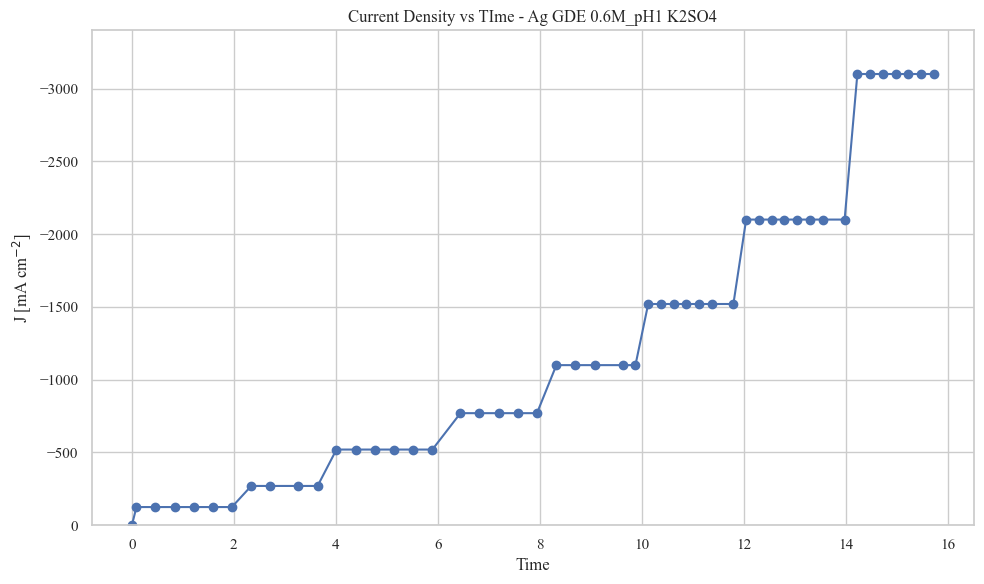

In [123]:
plt.figure(figsize=(10, 6)) 
plt.plot(Book["Duration / h"], Book['Current Density'], marker='o')  

plt.title('Current Density vs TIme - Ag GDE 0.6M_pH1 K2SO4')  
plt.xlabel('Time') 
plt.ylabel(r'J [mA cm$^{-2}$]') #Latex
plt.grid(True)
plt.ylim(0,-3400)
# plt.gca().set_xticklabels([])
# plt.xticks([])
plt.tight_layout()

plt.show()

## Current Density vs Flow Rate

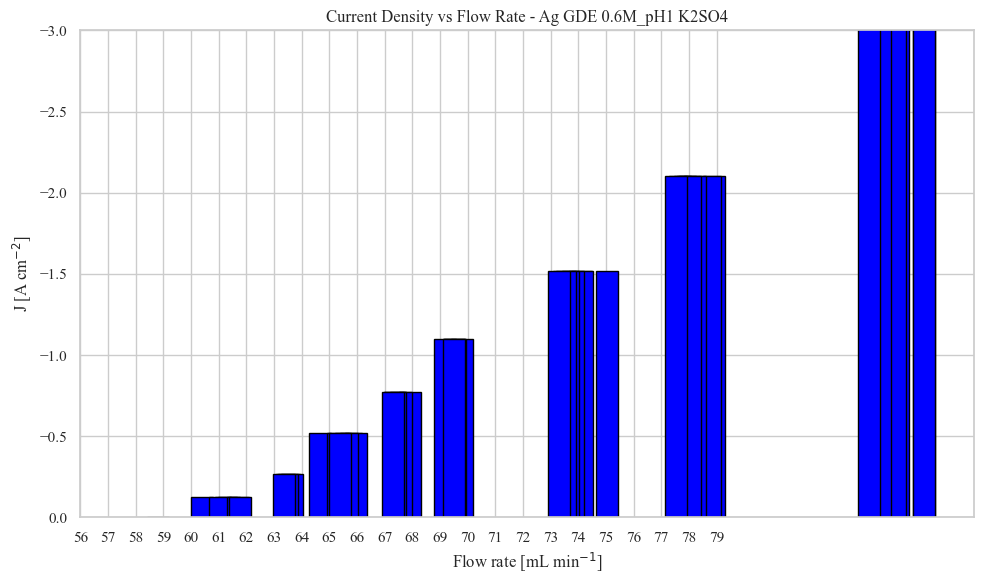

In [124]:
plt.figure(figsize=(10, 6)) 
plt.bar(Book["Flow rate (ml min-1)"], Book['Applied current / A'], color='blue', edgecolor='black')
plt.title('Current Density vs Flow Rate - Ag GDE 0.6M_pH1 K2SO4')  
plt.xlabel(r'Flow rate [mL min$^{-1}$]') 
plt.ylabel(r'J [A cm$^{-2}$]') #Latex
plt.grid(True)
plt.ylim(0, -3)
# plt.gca().set_xticklabels([])
plt.xticks(range(56,80,1))
plt.tight_layout()

plt.show()

C:\Users\GOVEAALP\AppData\Local\anaconda3\Lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
C:\Users\GOVEAALP\AppData\Local\anaconda3\Lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


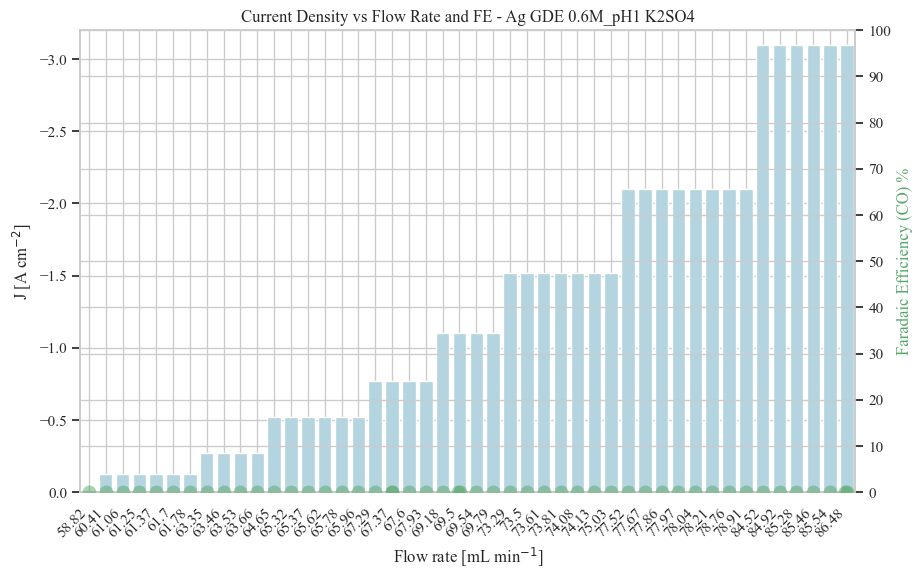

In [125]:
fig, ax1 = plt.subplots(figsize=(10, 6))

# Barplot for 'Applied current / A' on the left y-axis

sns.barplot(data=Book, x='Flow rate (ml min-1)', y='Applied current / A', ax=ax1, color='lightblue')

# Set the title and labels for the barplot
ax1.set_title('Current Density vs Flow Rate and FE - Ag GDE 0.6M_pH1 K2SO4')
ax1.set_xlabel(r'Flow rate [mL min$^{-1}$]')
ax1.set_ylabel(r'J [A cm$^{-2}$]')
ax1.set_ylim(0, -3.2)
ax1.grid(True)
ax1.set_xticklabels(ax1.get_xticklabels(), rotation=45, ha='right')

# Secondary right y-axis
ax2 = ax1.twinx()
sns.stripplot(data=Book, x='Flow rate (ml min-1)',  y='FE(CO)', ax=ax2, size=10, dodge=True, alpha=.5, legend=False, color='g')

# Set the label and limits for the secondary y-axis
ax2.set_ylabel('Faradaic Efficiency (CO) %', color='g')
ax2.set_ylim(0, 100)
ax2.set_yticks(np.arange(0, 101, 10))

# plt.savefig('20240531_Ag_GDE_0_6M_pH1_CD_FL_FE_barplot.png', dpi=300, bbox_inches='tight')
plt.show()

In [126]:
# g = sns.JointGrid(data=Book, x='Flow rate (ml min-1)',  y='Applied current / A', hue = 'FE(CO)')
# g.plot(sns.histplot, sns.kdeplot)

In [127]:
ls

 Volume in drive C is Windows
 Volume Serial Number is F86E-9ECB

 Directory of C:\Users\GOVEAALP\OneDrive - VITO\Documents\Experiments\2024\K2SO4\20240531 - Ag60 GDE_0.6 M K2SO4_pH1

11-Aug-26  08:48 AM    <DIR>          .
07-Jun-26  07:23 PM    <DIR>          ..
07-Jun-26  08:16 PM    <DIR>          .ipynb_checkpoints
14-Jun-24  12:01 PM           637,811 0.6M Cs2SO4_pH1.xlsx
01-Jun-24  04:50 PM            42,901 0p6M_pH1 K2SO4_20240601_1450_1min - Copy.xlsx
29-Jul-26  05:31 PM            57,059 0p6M_pH1 K2SO4_20240601_1450_1min.xlsx
01-Jun-24  04:50 PM            12,943 0p6M_pH1 K2SO4_20240601_1450_5min.xlsx
01-Jun-24  04:50 PM           348,181 0p6M_pH1 K2SO4_20240601_1450_Line_1.csv
12-May-25  01:59 PM           886,511 20240531 - Ag60 GDE_0.6 M K2SO4_pH1.ipynb
07-Jun-26  08:28 PM           600,979 20240531 - Ag60 GDE_0.6 M K2SO4_pH1-CORRECTED - Copy.ipynb
11-Aug-26  08:48 AM           529,763 20240531 - Ag60 GDE_0.6 M K2SO4_pH1-CORRECTED.ipynb
11-Aug-26  08:45 AM               54

## Current Density vs Duration (h)

C:\Users\GOVEAALP\AppData\Local\anaconda3\Lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
C:\Users\GOVEAALP\AppData\Local\anaconda3\Lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


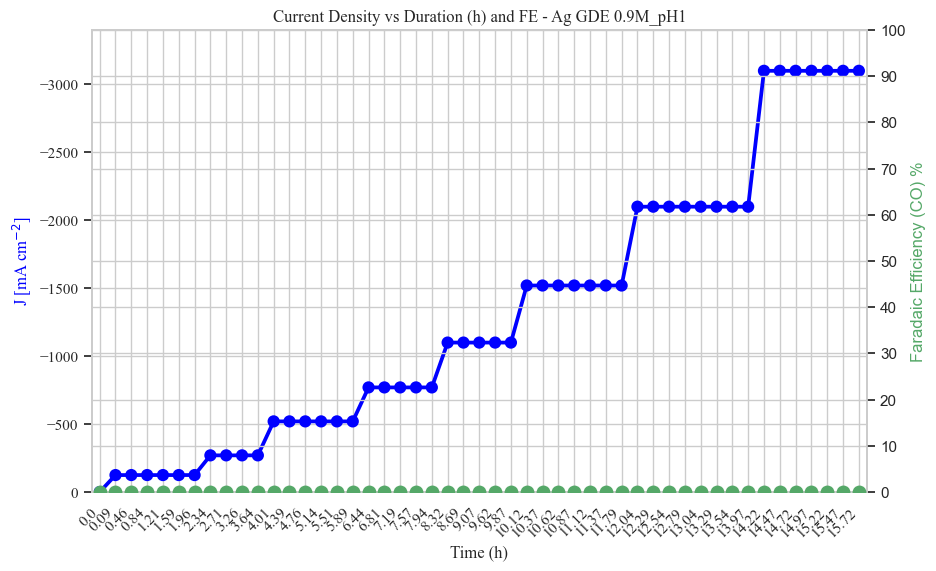

In [128]:
fig, ax1 = plt.subplots(figsize=(10, 6))

# Barplot for 'Applied current / A' on the left y-axis
sns.set(style="whitegrid")
sns.pointplot(data=Book, x='Duration / h', y='Current Density', ax=ax1, color='blue')

# Set the title and labels for the barplot
ax1.set_title('Current Density vs Duration (h) and FE - Ag GDE 0.9M_pH1')
ax1.set_xlabel('Time (h)')
ax1.set_ylabel(r'J [mA cm$^{-2}$]', color='blue')
ax1.set_ylim(0, -3400)
ax1.set_yticks(np.arange(0, -3400, -500))
ax1.grid(True)
ax1.set_xticklabels(ax1.get_xticklabels(), rotation=45, ha='right')

# Secondary right y-axis
ax2 = ax1.twinx()
sns.stripplot(data=Book, x='Duration / h',  y='FE(CO)', ax=ax2, size=10, dodge=True, alpha=1, legend=False, color = "g")

# Set the label and limits for the secondary y-axis
ax2.set_ylabel('Faradaic Efficiency (CO) %', color = "g")
ax2.set_ylim(0, 100)
ax2.set_yticks(np.arange(0, 101, 10))
# ax2.set_xticks(np.arange(0, 18, 1))
# ax2.set_xticklabels(np.arange(0, 18, 1))

# plt.savefig('20240531_Ag_GDE_0_6M_pH1_CD_Durat_FE_lineplot.png', dpi=300, bbox_inches='tight')
plt.show()

## Stacked bar plot

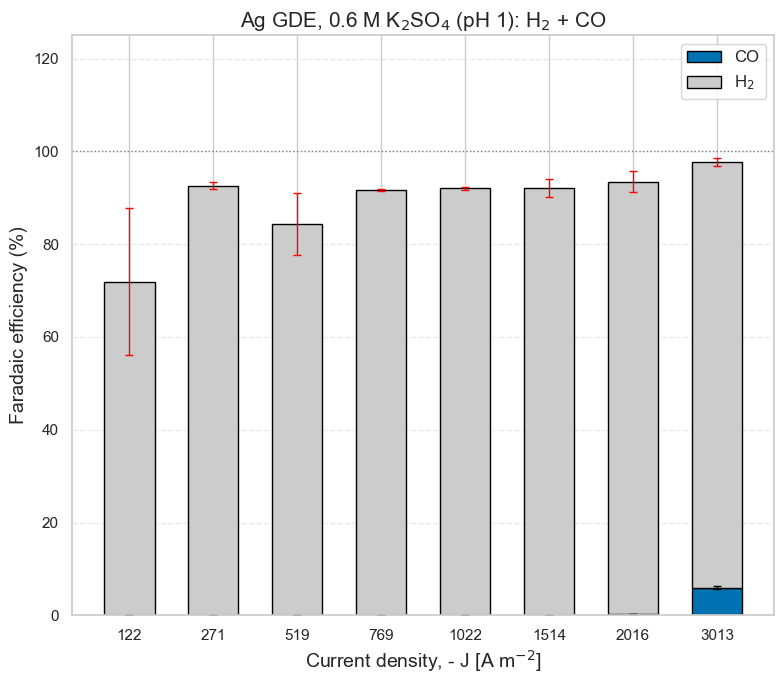

In [129]:
color_H2 = "#CCCCCC"
color_CO = "#0072B2"

fig, ax = plt.subplots(figsize=(8, 7))
x = np.arange(len(summary))
w = 0.6

# CO bottom
ax.bar(x, summary["FE_CO_mean"], w,
       color=color_CO, edgecolor="black", lw=1, label="CO")

# H2 stacked on CO
ax.bar(x, summary["FE_H2_mean"], w,
       bottom=summary["FE_CO_mean"],
       color=color_H2, edgecolor="black", lw=1, label=r"H$_2$")

# Error bars for CO (bottom segment)
ax.errorbar(x, summary["FE_CO_mean"],
            yerr=summary["FE_CO_sem"],
            fmt="none", ecolor="black", capsize=3, lw=1)

# Error bars for H2 (top segment → must be shifted by CO)
ax.errorbar(x, summary["FE_CO_mean"] + summary["FE_H2_mean"],
            yerr=summary["FE_H2_sem"],
            fmt="none", ecolor="red", capsize=3, lw=1)

ax.axhline(100, ls=":", color="grey", lw=1)

ax.set_xticks(x)
ax.set_xticklabels(summary["J (A m-2)"])

ax.set_xlabel(r"Current density, - J [A m$^{-2}$]", fontsize=14)
ax.set_ylabel("Faradaic efficiency (%)", fontsize=14)
ax.set_title(r"Ag GDE, 0.6 M K$_2$SO$_4$ (pH 1): H$_2$ + CO", fontsize=15)

ax.set_ylim(0, max(125, summary["FE_total_mean"].max()*1.05))

ax.grid(axis="y", ls="--", alpha=0.4)
ax.legend(fontsize=12, loc="upper right")

plt.tight_layout()
# plt.savefig("FE_H2_CO_stacked.png", dpi=300, bbox_inches="tight")
plt.show()

## Median

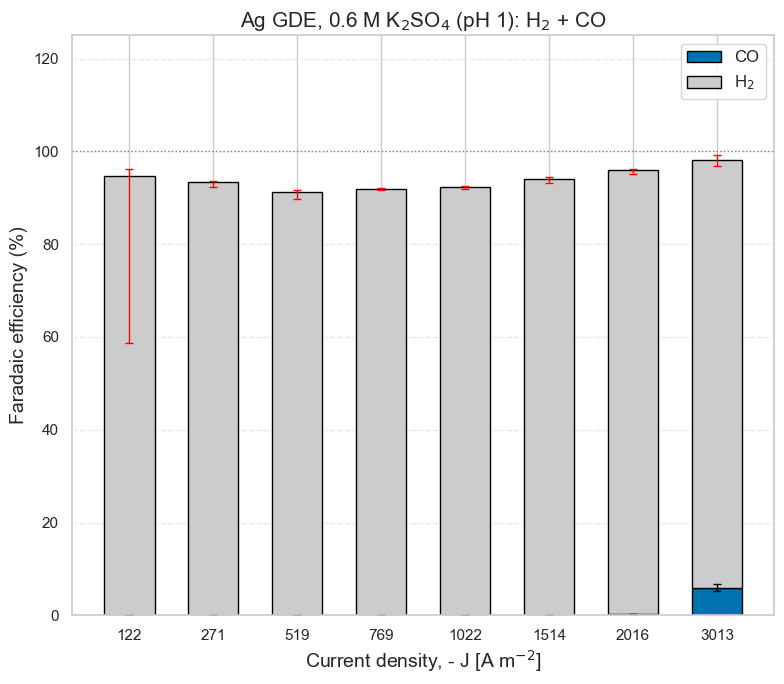

In [130]:
color_H2 = "#CCCCCC"
color_CO = "#0072B2"

fig, ax = plt.subplots(figsize=(8, 7))
x = np.arange(len(summary))
w = 0.6

# CO bottom
ax.bar(x, summary["FE_CO_median"], w,
       color=color_CO, edgecolor="black", lw=1, label="CO")

# H2 stacked on CO
ax.bar(x, summary["FE_H2_median"], w,
       bottom=summary["FE_CO_median"],
       color=color_H2, edgecolor="black", lw=1, label=r"H$_2$")

# Error bars for CO (median + IQR)
ax.errorbar(
    x,
    summary["FE_CO_median"],
    yerr=[
        summary["FE_CO_err_low"],
        summary["FE_CO_err_high"]
    ],
    fmt="none",
    ecolor="black",
    capsize=3,
    lw=1
)

# Error bars for H2 (shifted by CO + IQR)
ax.errorbar(
    x,
    summary["FE_CO_median"] + summary["FE_H2_median"],
    yerr=[
        summary["FE_H2_err_low"],
        summary["FE_H2_err_high"]
    ],
    fmt="none",
    ecolor="red",
    capsize=3,
    lw=1
)

ax.axhline(100, ls=":", color="grey", lw=1)

ax.set_xticks(x)
ax.set_xticklabels(summary["J (A m-2)"])

ax.set_xlabel(r"Current density, - J [A m$^{-2}$]", fontsize=14)
ax.set_ylabel("Faradaic efficiency (%)", fontsize=14)
ax.set_title(r"Ag GDE, 0.6 M K$_2$SO$_4$ (pH 1): H$_2$ + CO", fontsize=15)

ax.set_ylim(0, max(125, summary["FE_total_median"].max()*1.05))

ax.grid(axis="y", ls="--", alpha=0.4)
ax.legend(fontsize=12, loc="upper right")

plt.tight_layout()
# plt.savefig("FE_H2_CO_stacked_median_IQR.png", dpi=300, bbox_inches="tight")
plt.show()

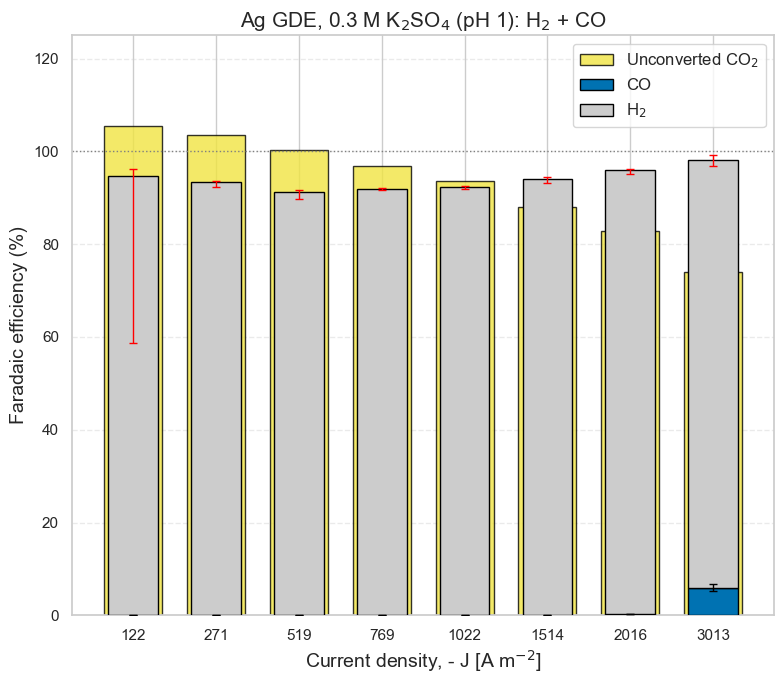

In [131]:
color_H2 = "#CCCCCC"
color_CO = "#0072B2"
color_CO2 = "#F0E442" #006C76

# okabe_ito = ['#000000', '#D55E00', '#56B4E9', '#F0E442',
             # '#0072B2', '#009E73', '#CC79A7', '#E69F00']

fig, ax = plt.subplots(figsize=(8, 7))
x = np.arange(len(summary))

# Widths
w_CO2 = 0.7   # wider background bar
w = 0.6       # CO + H2 foreground bars

# ---------------------------------------------------------
# UNCONVERTED CO2 — background, starts from zero
# ---------------------------------------------------------
ax.bar(
    x,
    summary["area_CO2_median"],
    w_CO2,
    color=color_CO2,
    alpha=0.8,
    edgecolor="black",
    lw=1,
    label=r"Unconverted CO$_2$",
    zorder=1
)

# ---------------------------------------------------------
# CO — foreground, starts from zero
# ---------------------------------------------------------
ax.bar(
    x,
    summary["FE_CO_median"],
    w,
    color=color_CO,
    edgecolor="black",
    lw=1,
    label="CO",
    zorder=3
)

# ---------------------------------------------------------
# H2 — stacked on CO
# ---------------------------------------------------------
ax.bar(
    x,
    summary["FE_H2_median"],
    w,
    bottom=summary["FE_CO_median"],
    color=color_H2,
    edgecolor="black",
    lw=1,
    label=r"H$_2$",
    zorder=3
)

# ---------------------------------------------------------
# Error bars for CO
# ---------------------------------------------------------
ax.errorbar(
    x,
    summary["FE_CO_median"],
    yerr=[
        summary["FE_CO_err_low"],
        summary["FE_CO_err_high"]
    ],
    fmt="none",
    ecolor="black",
    capsize=3,
    lw=1,
    zorder=4
)

# ---------------------------------------------------------
# Error bars for H2
# ---------------------------------------------------------
ax.errorbar(
    x,
    summary["FE_CO_median"] + summary["FE_H2_median"],
    yerr=[
        summary["FE_H2_err_low"],
        summary["FE_H2_err_high"]
    ],
    fmt="none",
    ecolor="red",
    capsize=3,
    lw=1,
    zorder=4
)

# 100% reference
ax.axhline(100, ls=":", color="grey", lw=1)

ax.set_xticks(x)
ax.set_xticklabels(summary["J (A m-2)"])

ax.set_xlabel(r"Current density, - J [A m$^{-2}$]", fontsize=14)
ax.set_ylabel("Faradaic efficiency (%)", fontsize=14)

ax.set_title(
    r"Ag GDE, 0.3 M K$_2$SO$_4$ (pH 1): H$_2$ + CO",
    fontsize=15
)

# Make sure the limit accounts for both types of bars
max_value = max(
    summary["area_CO2_median"].max(),
    (summary["FE_CO_median"] + summary["FE_H2_median"]).max()
)

ax.set_ylim(0, max(125, max_value * 1.05))

ax.grid(axis="y", ls="--", alpha=0.4)
ax.legend(fontsize=12, loc="upper right")

plt.tight_layout()
plt.savefig(
    "FE_H2_CO_CO2_median_IQR.png",
    dpi=300,
    bbox_inches="tight"
)
plt.show()

# Mean and Standard Deviation Applied Current and FE(CO)

In [78]:
standard_current_density = [
    100, 250, 500, 750,
    1000, 1500, 2000, 3000
]
summary["J (A m-2)_ps"] = summary["J (A m-2)"]
summary["J (A m-2)"] = standard_current_density #This is to have the same basis for later compare different experiments

In [79]:
Res_Book = summary.copy()

Res_Book = Res_Book.fillna(0)

Res_Book = Res_Book.rename(columns={
    # Mean
    "FE_H2_mean": "FE(H2)_mean",
    "FE_CO_mean": "FE(CO)_mean",
    "FE_total_mean": "FE(total)_mean",

    # Median
    "FE_H2_median": "FE(H2)_median",
    "FE_CO_median": "FE(CO)_median",
    "FE_total_median": "FE(total)_median",

    # Median error
    "FE_H2_q25": "FE(H2)_q25",
    "FE_H2_q75": "FE(H2)_q75",
    "FE_H2_err_low": "FE(H2)_err_low",
    "FE_H2_err_high": "FE(H2)_err_high",

    "FE_CO_q25": "FE(CO)_q25",
    "FE_CO_q75": "FE(CO)_q75",
    "FE_CO_err_low": "FE(CO)_err_low",
    "FE_CO_err_high": "FE(CO)_err_high",

    "FE_total_q25": "FE(total)_q25",
    "FE_total_q75": "FE(total)_q75",
    "FE_total_err_low": "FE(total)_err_low",
    "FE_total_err_high": "FE(total)_err_high",

    # SEM
    "FE_H2_sem": "FE(H2)_sem",
    "FE_CO_sem": "FE(CO)_sem",
    "FE_total_sem": "FE(total)_sem",

    # Standard deviation
    "FE_H2_std": "FE(H2)_std",
    "FE_CO_std": "FE(CO)_std",
    "FE_total_std": "FE(total)_std",

    # Current density
    "Current Density [A/m2]": "Current Density_mean"
})

Res_Book

,J (A m-2),FE(H2)_mean,FE(CO)_mean,FE(H2)_median,FE(CO)_median,FE(H2)_sem,FE(CO)_sem,FE(H2)_std,FE(CO)_std,FE(H2)_q25,...,c_H2_median,n,FE(H2)_err_low,FE(H2)_err_high,FE(CO)_err_low,FE(CO)_err_high,FE(total)_err_low,FE(total)_err_high,Time Interval (h),J (A m-2)_ps
0,100,71.883789,0.000000,94.744834,0.000000,15.805120,0.000000,41.816418,0.000000,58.753032,...,0.014738,7,35.991802,1.516115,0.000000,0.000000,35.991802,1.516115,0–2,122
1,250,92.612210,0.000000,93.297158,0.000000,0.824795,0.000000,1.649591,0.000000,92.400838,...,0.031285,4,0.896320,0.211372,0.000000,0.000000,0.896320,0.211372,2–4,271
2,500,84.372160,0.000000,91.270991,0.000000,6.752747,0.000000,16.540785,0.000000,89.767992,...,0.056614,6,1.503000,0.428486,0.000000,0.000000,1.503000,0.428486,4–6,519
3,750,91.628906,0.000000,91.839535,0.000000,0.261886,0.000000,0.585595,0.000000,91.695322,...,0.082041,5,0.144213,0.155156,0.000000,0.000000,0.144213,0.155156,6–8,769
4,1000,92.022518,0.000000,92.251397,0.000000,0.363839,0.000000,0.813568,0.000000,91.973126,...,0.106127,5,0.278271,0.234714,0.000000,0.000000,0.278271,0.234714,8–10,1022
5,1500,92.101781,0.000000,94.109507,0.000000,1.916159,0.000000,5.069680,0.000000,93.265260,...,0.151223,7,0.844247,0.319756,0.000000,0.000000,0.844247,0.319756,10–12,1514
6,2000,93.261065,0.211744,95.701377,0.236307,2.275003,0.027645,6.434680,0.078191,94.922034,...,0.193715,8,0.779343,0.270892,0.018828,0.020250,0.756035,0.287194,12–14,2016
7,3000,91.725347,5.988137,92.349400,5.886982,0.856563,0.339262,2.266253,0.897602,90.938828,...,0.254833,7,1.410572,0.946467,0.586221,0.805412,0.605161,0.360246,14–16,3013


In [82]:
Res_Book
# Res_Book.to_csv('20240531_0.6M K2SO4_pH1.csv')

,J (A m-2),FE(H2)_mean,FE(CO)_mean,FE(H2)_median,FE(CO)_median,FE(H2)_sem,FE(CO)_sem,FE(H2)_std,FE(CO)_std,FE(H2)_q25,...,c_H2_median,n,FE(H2)_err_low,FE(H2)_err_high,FE(CO)_err_low,FE(CO)_err_high,FE(total)_err_low,FE(total)_err_high,Time Interval (h),J (A m-2)_ps
0,100,71.883789,0.000000,94.744834,0.000000,15.805120,0.000000,41.816418,0.000000,58.753032,...,0.014738,7,35.991802,1.516115,0.000000,0.000000,35.991802,1.516115,0–2,122
1,250,92.612210,0.000000,93.297158,0.000000,0.824795,0.000000,1.649591,0.000000,92.400838,...,0.031285,4,0.896320,0.211372,0.000000,0.000000,0.896320,0.211372,2–4,271
2,500,84.372160,0.000000,91.270991,0.000000,6.752747,0.000000,16.540785,0.000000,89.767992,...,0.056614,6,1.503000,0.428486,0.000000,0.000000,1.503000,0.428486,4–6,519
3,750,91.628906,0.000000,91.839535,0.000000,0.261886,0.000000,0.585595,0.000000,91.695322,...,0.082041,5,0.144213,0.155156,0.000000,0.000000,0.144213,0.155156,6–8,769
4,1000,92.022518,0.000000,92.251397,0.000000,0.363839,0.000000,0.813568,0.000000,91.973126,...,0.106127,5,0.278271,0.234714,0.000000,0.000000,0.278271,0.234714,8–10,1022
5,1500,92.101781,0.000000,94.109507,0.000000,1.916159,0.000000,5.069680,0.000000,93.265260,...,0.151223,7,0.844247,0.319756,0.000000,0.000000,0.844247,0.319756,10–12,1514
6,2000,93.261065,0.211744,95.701377,0.236307,2.275003,0.027645,6.434680,0.078191,94.922034,...,0.193715,8,0.779343,0.270892,0.018828,0.020250,0.756035,0.287194,12–14,2016
7,3000,91.725347,5.988137,92.349400,5.886982,0.856563,0.339262,2.266253,0.897602,90.938828,...,0.254833,7,1.410572,0.946467,0.586221,0.805412,0.605161,0.360246,14–16,3013


## Mean and StD of FE(CO) through time

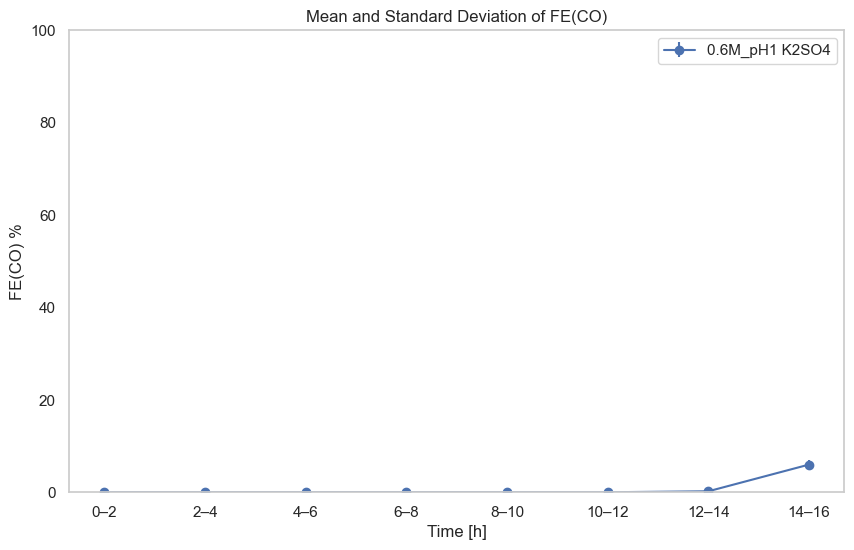

In [83]:
fig, ax = plt.subplots(figsize=(10, 6))

# Plot FE (CO) mean with standard deviation
ax.errorbar(Res_Book["Time Interval (h)"], Res_Book['FE(CO)_mean'],
            yerr=Res_Book['FE(CO)_std'], fmt='-o', label='0.6M_pH1 K2SO4')

# Formatting the plot
ax.set_xlabel('Time [h]')
ax.set_ylabel('FE(CO) %')
ax.set_title('Mean and Standard Deviation of FE(CO)')
ax.set_ylim(0,100)
ax.legend()
ax.grid(False)

# plt.savefig('20240531_0.6M_pH1_mean_std_time.png', dpi=300, bbox_inches='tight')
plt.show()

## Current Density vs FE(CO)_ mean and std

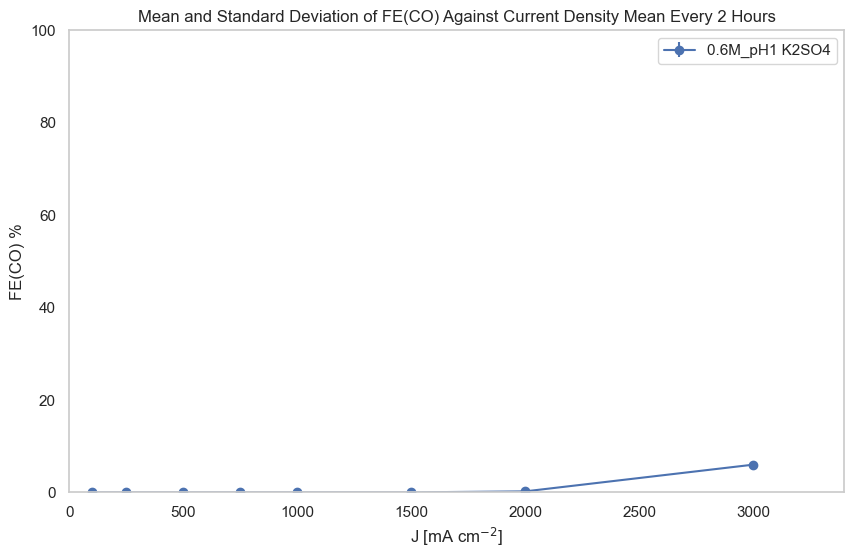

In [84]:
fig, ax = plt.subplots(figsize=(10, 6))

# Plot FE (CO) mean with standard deviation against Applied Current mean
ax.errorbar(Res_Book['J (A m-2)'], Res_Book['FE(CO)_mean'], 
            yerr=Res_Book['FE(CO)_std'], fmt='-o', label='0.6M_pH1 K2SO4')

# Formatting the plot
ax.set_xlabel(r'J [mA cm$^{-2}$]')
ax.set_ylabel('FE(CO) %')
ax.set_xlim(0,3400)
ax.set_ylim(0,100)
ax.set_title('Mean and Standard Deviation of FE(CO) Against Current Density Mean Every 2 Hours')
ax.legend()
ax.grid(False)

# plt.savefig('20240531_0.6M_pH1_mean_std_FE(CO)vsCD.png', dpi=300, bbox_inches='tight')
plt.show()